# Notebook 6 — Correlation Analysis

## Research question

> **Do plant signals reflect human emotion — as measured through Facial Emotion
> Recognition (FER) and Heart Rate Variability (HRV) — and do CO₂ / VOC
> correlate with those emotional states?**

This notebook performs a reproducible, statistically grounded correlation
analysis on the consolidated dataset (one row per 30-second window, produced by
Notebooks 1–3). It is structured as a self-contained scientific analysis
chapter: **methodology → assumption checks → analysis → interpretation**, kept
clearly separated.

### Two analysis axes

| # | Relationship | Variable types |
|---|---|---|
| **A** | Human **emotion** ↔ **CO₂ / VOC** | emotion = ordinal label + continuous FER valence/arousal; CO₂/VOC = continuous |
| **B** | **Plant signals** ↔ **CO₂ / VOC** | both continuous |

### A note on what "emotion" means here
Emotion is represented in two complementary ways:
1. the **discrete 3-class label** (`negativ` / `neutral` / `positiv`), an
   ordinal variable derived primarily from HRV, and
2. the **continuous FER outputs** (`fer_valence`, `fer_arousal`) plus the HRV
   metrics (`rmssd`, `mean_hr`), which give graded, continuous emotion proxies.

Using both lets us apply the statistically correct test for each
representation rather than forcing one method onto mismatched data types.

### VOC availability
VOC hardware was temporarily unavailable during recording. Every VOC analysis is
therefore implemented **in full** but gated behind a single switch
`ENABLE_VOC = False`. Set it to `True` once VOC data is present and the VOC
sections run automatically with no further changes.


## 0  Methodology

### Choosing a correlation coefficient
The appropriate coefficient depends on the data:

| Coefficient | Assumes | Use when |
|---|---|---|
| **Pearson r** | linear relationship, both variables ~normal | continuous, normal, linear |
| **Spearman ρ** | monotonic relationship (rank-based) | continuous non-normal, or ordinal, or non-linear-but-monotonic |
| **Kendall τ** | monotonic; robust for small N / many ties | small samples, many tied ranks |

We **do not** pick one blindly. For each continuous–continuous pair we:
1. test each variable for **normality** (Shapiro–Wilk),
2. assess **linearity** visually (scatter + LOWESS) and via the
   Pearson-vs-Spearman gap,
3. report **Pearson** when both variables are approximately normal, otherwise
   **Spearman** as the primary coefficient, and additionally report **Kendall τ**
   because the per-session sample sizes here are modest.

### Emotion (ordinal label) vs. a continuous variable
The 3-class label is ordinal, so a product-moment correlation is inappropriate
against it directly. Instead we use:
- **Kruskal–Wallis H test** — non-parametric test of whether the continuous
  variable (e.g. CO₂) differs across the three emotion groups,
- **Spearman ρ / Kendall τ** on the integer-coded ordinal label
  (negativ=−1, neutral=0, positiv=+1) to quantify a monotonic trend,
- **ε² (epsilon-squared)** as the effect size for Kruskal–Wallis.

### Significance and multiple comparisons
All tests report exact **p-values**. Because we run many correlations, we apply
a **Benjamini–Hochberg** false-discovery-rate (FDR) correction within each
analysis family and report both raw and adjusted p-values. We treat
**α = 0.05** on the FDR-adjusted p-value as the significance threshold.

### Effect-size interpretation (Cohen's conventions)
| |r| or |ρ| | Interpretation |
|---|---|
| < 0.10 | negligible |
| 0.10–0.29 | small |
| 0.30–0.49 | moderate |
| ≥ 0.50 | large |

### Reproducibility & honesty about power
A fixed random seed is set. **Caveat:** this is an exploratory pilot dataset.
With few participants, correlation estimates have wide confidence intervals and
non-significant results must not be read as evidence of *no* effect. The
analysis is built to scale unchanged to the full cohort.


## 1  Configuration & Imports

All switches live here. `ENABLE_VOC` is the single control that activates every
VOC analysis once data is available.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

# statsmodels for FDR correction and LOWESS smoothing (optional but recommended)
try:
    from statsmodels.stats.multitest import multipletests
    from statsmodels.nonparametric.smoothers_lowess import lowess
    STATSMODELS_OK = True
except ImportError:
    STATSMODELS_OK = False
    print("statsmodels not installed — FDR correction & LOWESS disabled "
          "(pip install statsmodels). Falling back to raw p-values.")

# ══════════════════════════════════════════════════════════════════
# CONFIGURATION
# ══════════════════════════════════════════════════════════════════
DATASET_CSV  = Path("./consolidated_dataset.csv")   # output of Notebook 1

ENABLE_VOC   = False        # ← set True once VOC data is recorded
VOC_COLUMN   = "voc_mean"   # expected VOC column name when available
CO2_COLUMN   = "co2_mean"

ALPHA        = 0.05         # significance threshold (on FDR-adjusted p)
NORMALITY_ALPHA = 0.05      # Shapiro–Wilk threshold for "normal"
RANDOM_STATE = 42

# Ordinal coding of the emotion label
LABEL_ORDER  = ["negativ", "neutral", "positiv"]
LABEL_CODE   = {"negativ": -1, "neutral": 0, "positiv": 1}

np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 200

print(f"Dataset    : {DATASET_CSV.resolve()}")
print(f"ENABLE_VOC : {ENABLE_VOC}")
print(f"statsmodels: {STATSMODELS_OK}")


Dataset    : /Users/jakobjetter/Documents/Universität zu Köln/2. Semester/COIN Seminar/Project/COIN2026_Team-1_Plant-Emotion-Detector/notebooks/consolidated_dataset.csv
ENABLE_VOC : False
statsmodels: True


## 2  Load Data & Define Variable Groups

We load the consolidated dataset and organise the columns into the conceptual
groups used throughout the analysis. Windows labelled `excluded` (no usable
emotion) are removed.


In [2]:
if not DATASET_CSV.exists():
    raise FileNotFoundError(
        f"{DATASET_CSV.resolve()} not found. Run Notebook 1 (dataset creation) first."
    )

df = pd.read_csv(DATASET_CSV)
print(f"Loaded {df.shape[0]} rows × {df.shape[1]} columns")

# Remove excluded windows if any slipped through
if "label" in df.columns:
    df = df[df["label"] != "excluded"].copy()

# ── Variable groups ──────────────────────────────────────────────
emotion_label   = "label"
emotion_cont    = [c for c in ["fer_valence", "fer_arousal", "rmssd", "mean_hr"]
                   if c in df.columns]                      # continuous emotion proxies
plant_features  = [c for c in [
    "plant_mean","plant_median","plant_std","plant_iqr","plant_min","plant_max",
    "plant_range","plant_rms","plant_zcr",
    "bp_0_1","bp_1_5","bp_5_15","bp_15_30","bp_30_50","total_power"
] if c in df.columns]

env_cols = []
if CO2_COLUMN in df.columns: env_cols.append(CO2_COLUMN)
if ENABLE_VOC:
    if VOC_COLUMN in df.columns:
        env_cols.append(VOC_COLUMN)
    else:
        print(f"⚠ ENABLE_VOC=True but '{VOC_COLUMN}' not in dataset — VOC skipped.")

# Add an ordinal numeric code for the label
df["label_ord"] = df[emotion_label].map(LABEL_CODE)

print(f"\nEmotion label      : {emotion_label}  (ordinal code in 'label_ord')")
print(f"Continuous emotion : {emotion_cont}")
print(f"Plant features     : {len(plant_features)} columns")
print(f"Environment        : {env_cols}  (VOC {'on' if ENABLE_VOC else 'off'})")
print(f"\nLabel distribution:\n{df[emotion_label].value_counts().to_string()}")

# Drop CO2 NaNs for the environment analyses (keep a clean copy)
def valid_pairs(frame, a, b):
    """Return the subset of `frame` where both columns a, b are finite."""
    sub = frame[[a, b]].apply(pd.to_numeric, errors="coerce").dropna()
    return sub[a].values, sub[b].values


Loaded 456 rows × 42 columns

Emotion label      : label  (ordinal code in 'label_ord')
Continuous emotion : ['fer_valence', 'fer_arousal', 'rmssd', 'mean_hr']
Plant features     : 15 columns
Environment        : ['co2_mean']  (VOC off)

Label distribution:
label
neutral    205
positiv    142
negativ    109


## 3  Assumption Checks: Normality & Distributions

Before choosing coefficients we examine the distribution of every continuous
variable. The **Shapiro–Wilk** test assesses normality (H₀: data are normal; a
p-value below `NORMALITY_ALPHA` rejects normality). We also plot histograms so
the decision is transparent rather than purely test-driven.

The outcome of this section decides, per variable, whether Pearson (normal) or
Spearman (non-normal) is the primary coefficient downstream.


In [3]:
def normality_table(frame, columns):
    """Shapiro–Wilk normality test for each column. Returns a tidy DataFrame."""
    rows = []
    for c in columns:
        x = pd.to_numeric(frame[c], errors="coerce").dropna().values
        if len(x) < 3 or np.std(x) == 0:
            rows.append({"variable": c, "n": len(x), "W": np.nan,
                         "p_value": np.nan, "normal": False})
            continue
        # Shapiro is reliable up to ~5000 samples; subsample if larger
        xs = x if len(x) <= 5000 else np.random.choice(x, 5000, replace=False)
        W, p = stats.shapiro(xs)
        rows.append({"variable": c, "n": len(x), "W": round(W, 4),
                     "p_value": p, "normal": bool(p > NORMALITY_ALPHA)})
    return pd.DataFrame(rows)

continuous_vars = emotion_cont + plant_features + env_cols
norm_df = normality_table(df, continuous_vars)
print("Shapiro–Wilk normality test (normal = p > %.2f):\n" % NORMALITY_ALPHA)
print(norm_df.to_string(index=False))

# Store a quick lookup: is this variable normal?
IS_NORMAL = dict(zip(norm_df["variable"], norm_df["normal"]))
n_normal = norm_df["normal"].sum()
print(f"\n{n_normal}/{len(norm_df)} continuous variables are approximately normal.")
print("→ Variables failing normality will use Spearman (rank-based) as primary.")


Shapiro–Wilk normality test (normal = p > 0.05):

    variable   n      W      p_value  normal
 fer_valence 456 0.9274 4.653635e-14   False
 fer_arousal 456 0.8680 3.277992e-19   False
       rmssd 456 0.8570 5.715944e-20   False
     mean_hr 456 0.8412 5.578879e-21   False
  plant_mean 456 0.7984 2.174101e-23   False
plant_median 456 0.8304 1.247560e-21   False
   plant_std 456 0.9359 4.194352e-13   False
   plant_iqr 456 0.9413 1.917109e-12   False
   plant_min 456 0.2442 2.806035e-39   False
   plant_max 456 0.9691 3.199736e-08   False
 plant_range 456 0.3871 1.801825e-36   False
   plant_rms 456 0.7988 2.280744e-23   False
   plant_zcr 456 0.9379 7.432144e-13   False
      bp_0_1 456 0.9043 2.457248e-16   False
      bp_1_5 456 0.1149 1.822939e-41   False
     bp_5_15 456 0.2257 1.309809e-39   False
    bp_15_30 456 0.5876 1.849511e-31   False
    bp_30_50 456 0.6415 8.818357e-30   False
 total_power 456 0.7114 2.810674e-27   False
    co2_mean 456 0.8808 2.863085e-18   False

0/20

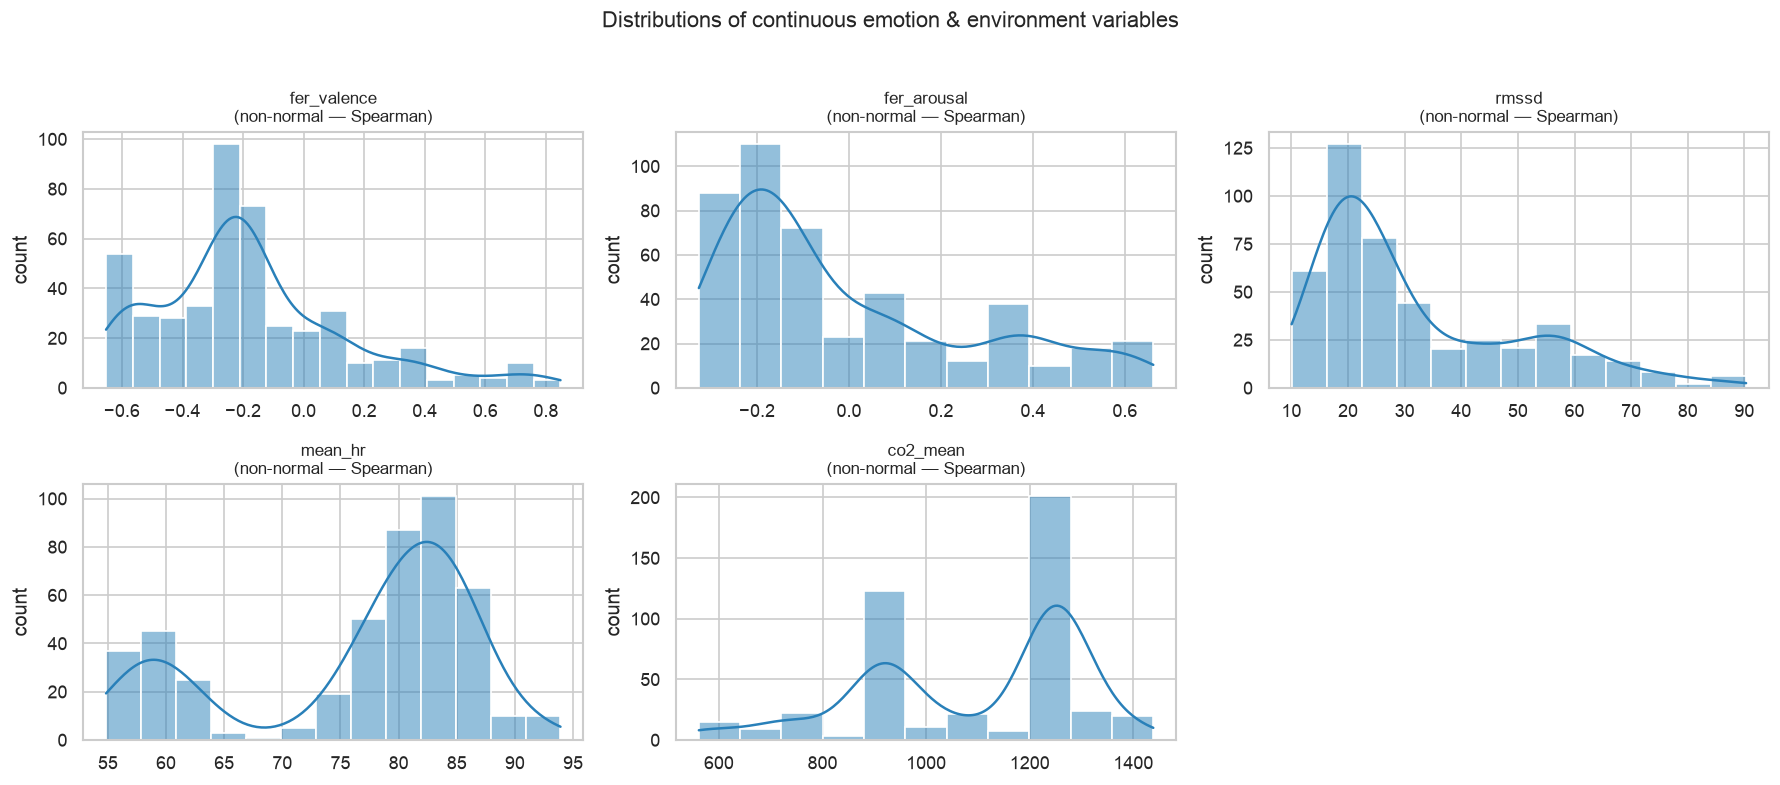

In [4]:
# Distribution plots for the key continuous variables
plot_vars = [v for v in (emotion_cont + env_cols) if v in df.columns]
if plot_vars:
    ncols = 3
    nrows = int(np.ceil(len(plot_vars) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3.2*nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax, v in zip(axes, plot_vars):
        x = pd.to_numeric(df[v], errors="coerce").dropna()
        sns.histplot(x, kde=True, ax=ax, color="#2980b9", edgecolor="white")
        normal = IS_NORMAL.get(v, False)
        ax.set_title(f"{v}\n({'normal' if normal else 'non-normal'} — "
                     f"{'Pearson' if normal else 'Spearman'})", fontsize=10)
        ax.set_xlabel(""); ax.set_ylabel("count")
    for ax in axes[len(plot_vars):]:
        ax.set_visible(False)
    plt.suptitle("Distributions of continuous emotion & environment variables",
                 y=1.02, fontsize=13)
    plt.tight_layout(); plt.show()
else:
    print("No continuous emotion/environment variables available to plot.")


## 4  Statistical Engine (reusable functions)

To keep the analysis modular and reproducible, all statistics are computed by a
small set of well-defined functions used by both analysis axes:

- `correlation_test` — continuous↔continuous, auto-selects Pearson or Spearman
  based on the normality of both variables, and always also reports Kendall τ.
- `effect_label` — maps a coefficient to a Cohen interpretation.
- `kruskal_by_group` — Kruskal–Wallis across the three emotion groups, with ε²
  effect size.
- `fdr_adjust` — Benjamini–Hochberg adjustment of a list of p-values.

Each returns plain dictionaries / DataFrames so results are easy to inspect and
export.


In [5]:
def effect_label(coef):
    """Cohen-style interpretation of an absolute correlation coefficient."""
    a = abs(coef)
    if np.isnan(a):      return "n/a"
    if a < 0.10:         return "negligible"
    if a < 0.30:         return "small"
    if a < 0.50:         return "moderate"
    return "large"

def correlation_test(x, y, x_normal, y_normal):
    """Continuous-continuous correlation. Picks Pearson if BOTH variables are
    approximately normal, else Spearman as primary. Always reports Kendall too."""
    x = np.asarray(x, float); y = np.asarray(y, float)
    n = len(x)
    out = {"n": n}
    if n < 3 or np.std(x) == 0 or np.std(y) == 0:
        out.update(primary_method="n/a", primary_r=np.nan, primary_p=np.nan,
                   pearson_r=np.nan, pearson_p=np.nan,
                   spearman_r=np.nan, spearman_p=np.nan,
                   kendall_tau=np.nan, kendall_p=np.nan, effect="n/a")
        return out
    pr, pp = stats.pearsonr(x, y)
    sr, sp = stats.spearmanr(x, y)
    kt, kp = stats.kendalltau(x, y)
    use_pearson = bool(x_normal and y_normal)
    out.update(
        primary_method = "Pearson" if use_pearson else "Spearman",
        primary_r = pr if use_pearson else sr,
        primary_p = pp if use_pearson else sp,
        pearson_r=pr, pearson_p=pp,
        spearman_r=sr, spearman_p=sp,
        kendall_tau=kt, kendall_p=kp,
    )
    out["effect"] = effect_label(out["primary_r"])
    return out

def kruskal_by_group(frame, value_col, group_col=emotion_label, order=LABEL_ORDER):
    """Kruskal–Wallis H test of `value_col` across emotion groups + epsilon² effect size."""
    groups, names = [], []
    for g in order:
        vals = pd.to_numeric(frame.loc[frame[group_col] == g, value_col],
                             errors="coerce").dropna().values
        if len(vals) > 0:
            groups.append(vals); names.append(g)
    if len(groups) < 2:
        return {"H": np.nan, "p_value": np.nan, "epsilon_sq": np.nan,
                "groups": names, "n_total": int(sum(len(g) for g in groups))}
    H, p = stats.kruskal(*groups)
    N = sum(len(g) for g in groups); k = len(groups)
    # epsilon-squared effect size for Kruskal–Wallis
    eps_sq = (H - k + 1) / (N - k) if (N - k) > 0 else np.nan
    return {"H": H, "p_value": p, "epsilon_sq": eps_sq,
            "groups": names, "n_total": int(N)}

def fdr_adjust(pvals):
    """Benjamini–Hochberg FDR adjustment. Falls back to raw p if statsmodels missing."""
    p = np.asarray(pvals, float)
    mask = ~np.isnan(p)
    adj = np.full_like(p, np.nan)
    if mask.sum() == 0:
        return adj
    if STATSMODELS_OK:
        adj[mask] = multipletests(p[mask], method="fdr_bh")[1]
    else:
        adj[mask] = p[mask]   # no correction available
    return adj

print("Statistical engine ready: correlation_test, kruskal_by_group, "
      "fdr_adjust, effect_label.")


Statistical engine ready: correlation_test, kruskal_by_group, fdr_adjust, effect_label.


## 5  Analysis A — Emotion ↔ CO₂ / VOC

**Question.** Do CO₂ (and later VOC) levels relate to the participant's
emotional state?

We approach this with both emotion representations:

**A1 — Discrete emotion label (ordinal).**
Kruskal–Wallis tests whether CO₂ differs across the three emotion groups, with
ε² as effect size; Spearman/Kendall on the ordinal code quantify any monotonic
trend (does CO₂ rise/fall from negative→neutral→positive?).

**A2 — Continuous emotion proxies.**
Correlate CO₂ against `fer_valence`, `fer_arousal`, `rmssd`, `mean_hr` using the
auto-selected coefficient.


In [6]:
def analyse_emotion_vs_env(frame, env_col):
    """Run A1 (group test + ordinal trend) and A2 (continuous proxies) for one
    environment variable. Returns (kruskal_dict, ordinal_dict, continuous_df)."""
    # A1: Kruskal–Wallis across emotion groups
    kw = kruskal_by_group(frame, env_col)

    # A1: ordinal monotonic trend (Spearman + Kendall on label_ord)
    x, y = valid_pairs(frame, "label_ord", env_col)
    if len(x) >= 3 and np.std(y) > 0:
        sr, sp = stats.spearmanr(x, y)
        kt, kp = stats.kendalltau(x, y)
        ordinal = {"spearman_r": sr, "spearman_p": sp,
                   "kendall_tau": kt, "kendall_p": kp,
                   "effect": effect_label(sr), "n": len(x)}
    else:
        ordinal = {"spearman_r": np.nan, "spearman_p": np.nan,
                   "kendall_tau": np.nan, "kendall_p": np.nan,
                   "effect": "n/a", "n": len(x)}

    # A2: continuous emotion proxies vs env
    rows = []
    for em in emotion_cont:
        xv, yv = valid_pairs(frame, em, env_col)
        res = correlation_test(xv, yv, IS_NORMAL.get(em, False),
                               IS_NORMAL.get(env_col, False))
        rows.append({"emotion_proxy": em, **res})
    cont_df = pd.DataFrame(rows)
    if not cont_df.empty:
        cont_df["p_adj"] = fdr_adjust(cont_df["primary_p"].values)
        cont_df["significant"] = cont_df["p_adj"] < ALPHA
    return kw, ordinal, cont_df


# Run for CO2 (and VOC if enabled)
emotion_env_results = {}
for env_col in env_cols:
    print("=" * 64)
    print(f"  EMOTION ↔ {env_col.upper()}")
    print("=" * 64)
    kw, ordinal, cont_df = analyse_emotion_vs_env(df, env_col)
    emotion_env_results[env_col] = {"kruskal": kw, "ordinal": ordinal, "continuous": cont_df}

    print(f"\nA1 — Kruskal–Wallis across emotion groups {kw['groups']}:")
    print(f"     H = {kw['H']:.3f},  p = {kw['p_value']:.4f},  "
          f"ε² = {kw['epsilon_sq']:.4f}  (n = {kw['n_total']})")
    sig = "yes" if (not np.isnan(kw['p_value']) and kw['p_value'] < ALPHA) else "no"
    print(f"     CO₂/VOC differs across emotion groups? {sig}")

    print(f"\nA1 — Ordinal monotonic trend (negativ→neutral→positiv):")
    print(f"     Spearman ρ = {ordinal['spearman_r']:.3f} (p={ordinal['spearman_p']:.4f}), "
          f"Kendall τ = {ordinal['kendall_tau']:.3f} (p={ordinal['kendall_p']:.4f}) "
          f"[{ordinal['effect']}]")

    print(f"\nA2 — Continuous emotion proxies vs {env_col}:")
    show = cont_df[["emotion_proxy","primary_method","primary_r",
                    "primary_p","p_adj","effect","significant","n"]].copy()
    show[["primary_r","primary_p","p_adj"]] = show[["primary_r","primary_p","p_adj"]].round(4)
    print(show.to_string(index=False))
    print()

if not env_cols:
    print("No environment variables available (CO₂ missing and VOC disabled).")


  EMOTION ↔ CO2_MEAN

A1 — Kruskal–Wallis across emotion groups ['negativ', 'neutral', 'positiv']:
     H = 0.367,  p = 0.8325,  ε² = -0.0036  (n = 456)
     CO₂/VOC differs across emotion groups? no

A1 — Ordinal monotonic trend (negativ→neutral→positiv):
     Spearman ρ = -0.003 (p=0.9531), Kendall τ = -0.000 (p=0.9929) [negligible]

A2 — Continuous emotion proxies vs co2_mean:
emotion_proxy primary_method  primary_r  primary_p  p_adj   effect  significant   n
  fer_valence       Spearman    -0.3285     0.0000 0.0000 moderate         True 456
  fer_arousal       Spearman     0.4393     0.0000 0.0000 moderate         True 456
        rmssd       Spearman     0.1550     0.0009 0.0012    small         True 456
      mean_hr       Spearman    -0.1300     0.0054 0.0054    small         True 456



### 5.1  Visualisation — Emotion vs CO₂ / VOC

- **Violin + box plots** show the full distribution of CO₂ within each emotion
  group (the visual counterpart of the Kruskal–Wallis test).
- **Scatter + regression** shows CO₂ against the continuous FER valence with the
  fitted trend.


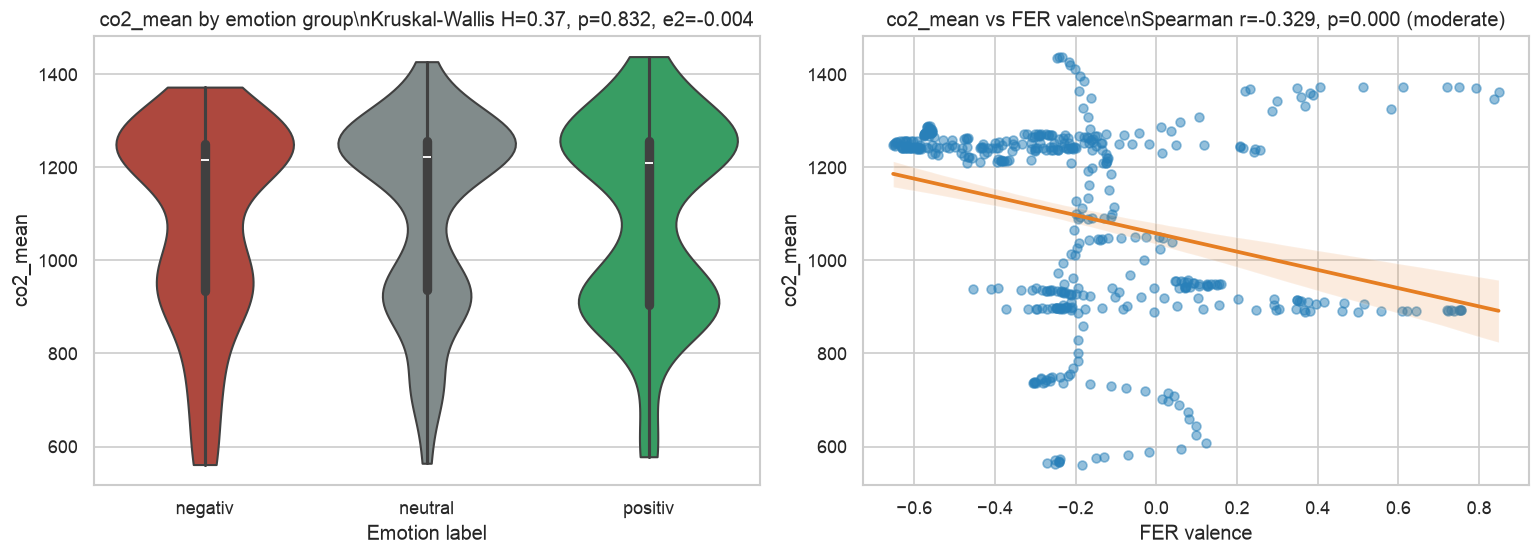

In [7]:
for env_col in env_cols:
    # Guard: skip plotting if this environment column has no usable data
    env_valid = pd.to_numeric(df[env_col], errors="coerce").notna().sum()
    if env_valid < 3:
        print(f"Skipping {env_col} plots — only {env_valid} valid values.")
        continue

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

    # Violin + box: env by emotion group (only groups that have data)
    order = [g for g in LABEL_ORDER
             if g in df[emotion_label].unique()
             and pd.to_numeric(df.loc[df[emotion_label]==g, env_col],
                               errors="coerce").notna().sum() > 0]
    palette = {"negativ":"#c0392b","neutral":"#7f8c8d","positiv":"#27ae60"}
    plot_df = df[[emotion_label, env_col]].copy()
    plot_df[env_col] = pd.to_numeric(plot_df[env_col], errors="coerce")
    plot_df = plot_df.dropna(subset=[env_col])

    sns.violinplot(data=plot_df, x=emotion_label, y=env_col, order=order,
                   palette=palette, inner="box", cut=0, ax=axes[0])
    kw = emotion_env_results[env_col]["kruskal"]
    axes[0].set_title(f"{env_col} by emotion group\\n"
                      f"Kruskal-Wallis H={kw['H']:.2f}, p={kw['p_value']:.3f}, "
                      f"e2={kw['epsilon_sq']:.3f}")
    axes[0].set_xlabel("Emotion label"); axes[0].set_ylabel(env_col)

    # Scatter + regression vs FER valence (if available)
    if "fer_valence" in df.columns:
        sub = df[["fer_valence", env_col]].apply(pd.to_numeric, errors="coerce").dropna()
        if len(sub) >= 3:
            sns.regplot(data=sub, x="fer_valence", y=env_col, ax=axes[1],
                        scatter_kws={"alpha":0.5,"s":28,"color":"#2980b9"},
                        line_kws={"color":"#e67e22"})
            cont_df = emotion_env_results[env_col]["continuous"]
            row = cont_df[cont_df["emotion_proxy"]=="fer_valence"]
            if not row.empty:
                r = row.iloc[0]
                axes[1].set_title(f"{env_col} vs FER valence\\n"
                                  f"{r['primary_method']} r={r['primary_r']:.3f}, "
                                  f"p={r['primary_p']:.3f} ({r['effect']})")
            axes[1].set_xlabel("FER valence"); axes[1].set_ylabel(env_col)
        else:
            axes[1].set_visible(False)
    else:
        axes[1].set_visible(False)
    plt.tight_layout(); plt.show()


## 6  Analysis B — Plant Signals ↔ CO₂ / VOC

**Question.** Do the plant bioelectric features co-vary with CO₂ (and later
VOC)? Both sides are continuous, so this is a continuous–continuous correlation
analysis. For every plant feature we run `correlation_test` (auto Pearson /
Spearman + Kendall) against the environment variable, then FDR-correct across
all plant features.

This is the most direct statistical test of *"do plant signals track the
environment"*, and a useful control: if plant features correlate strongly with
CO₂, any later plant↔emotion link must be interpreted with the environment as a
potential confounder.


In [8]:
def analyse_plant_vs_env(frame, env_col):
    rows = []
    for pf in plant_features:
        xv, yv = valid_pairs(frame, pf, env_col)
        res = correlation_test(xv, yv, IS_NORMAL.get(pf, False),
                               IS_NORMAL.get(env_col, False))
        rows.append({"plant_feature": pf, **res})
    res_df = pd.DataFrame(rows)
    if not res_df.empty:
        res_df["p_adj"] = fdr_adjust(res_df["primary_p"].values)
        res_df["significant"] = res_df["p_adj"] < ALPHA
        res_df = res_df.sort_values("primary_p", na_position="last").reset_index(drop=True)
    return res_df


plant_env_results = {}
for env_col in env_cols:
    print("=" * 64)
    print(f"  PLANT SIGNALS ↔ {env_col.upper()}")
    print("=" * 64)
    res_df = analyse_plant_vs_env(df, env_col)
    plant_env_results[env_col] = res_df
    show = res_df[["plant_feature","primary_method","primary_r",
                   "primary_p","p_adj","effect","significant","n"]].copy()
    show[["primary_r","primary_p","p_adj"]] = show[["primary_r","primary_p","p_adj"]].round(4)
    print(show.to_string(index=False))
    n_sig = int(res_df["significant"].sum()) if "significant" in res_df else 0
    print(f"\nSignificant plant–{env_col} correlations after FDR: {n_sig}/{len(res_df)}")
    print()

if not env_cols:
    print("No environment variables available — Analysis B skipped.")


  PLANT SIGNALS ↔ CO2_MEAN
plant_feature primary_method  primary_r  primary_p  p_adj     effect  significant   n
    plant_zcr       Spearman     0.5617     0.0000 0.0000      large         True 456
     bp_15_30       Spearman    -0.5189     0.0000 0.0000      large         True 456
    plant_max       Spearman    -0.5162     0.0000 0.0000      large         True 456
    plant_rms       Spearman    -0.4880     0.0000 0.0000   moderate         True 456
   plant_mean       Spearman    -0.4865     0.0000 0.0000   moderate         True 456
    plant_iqr       Spearman    -0.4781     0.0000 0.0000   moderate         True 456
    plant_std       Spearman    -0.4610     0.0000 0.0000   moderate         True 456
 plant_median       Spearman    -0.4269     0.0000 0.0000   moderate         True 456
  plant_range       Spearman    -0.3781     0.0000 0.0000   moderate         True 456
  total_power       Spearman    -0.3195     0.0000 0.0000   moderate         True 456
     bp_30_50       Spearma

### 6.1  Correlation Matrix Heatmap

A single heatmap of the **Spearman** correlation matrix across the continuous
emotion proxies, the most informative plant features, and the environment
variable(s). Spearman is used for the matrix because several variables are
non-normal (Section 3); it captures monotonic relationships uniformly. This
gives an at-a-glance map of where associations cluster.


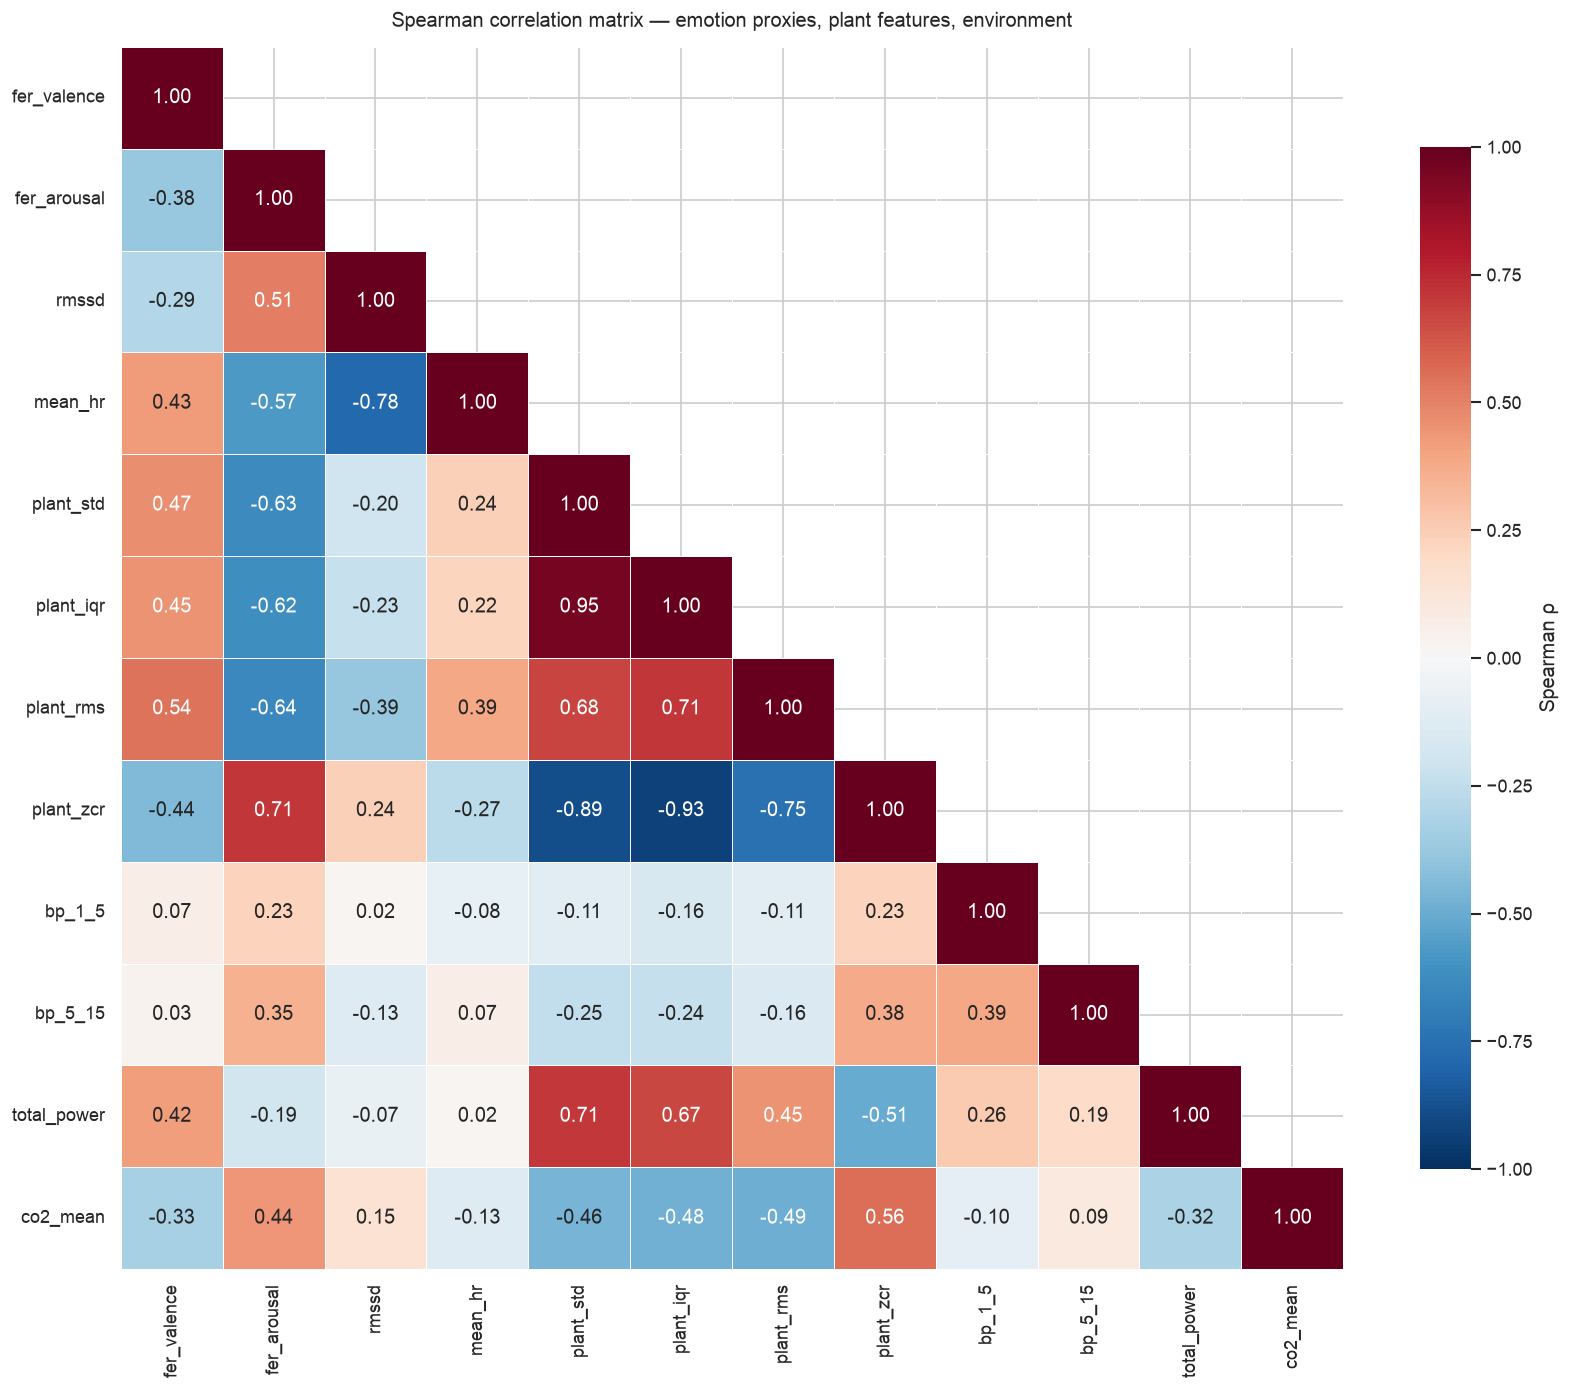

In [9]:
# Assemble a focused set of continuous variables for the matrix
matrix_vars = []
matrix_vars += [c for c in ["fer_valence","fer_arousal","rmssd","mean_hr"] if c in df.columns]
# pick the most variable plant features to keep the matrix readable
key_plant = [c for c in ["plant_std","plant_iqr","plant_rms","plant_zcr",
                         "bp_1_5","bp_5_15","total_power"] if c in df.columns]
matrix_vars += key_plant
matrix_vars += env_cols
matrix_vars = list(dict.fromkeys(matrix_vars))   # de-dup, keep order

mat = df[matrix_vars].apply(pd.to_numeric, errors="coerce")
corr = mat.corr(method="spearman")

fig, ax = plt.subplots(figsize=(1.0*len(matrix_vars)+2, 0.9*len(matrix_vars)+1))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={"label":"Spearman ρ","shrink":0.8}, ax=ax)
ax.set_title("Spearman correlation matrix — emotion proxies, plant features, environment",
             fontsize=12, pad=12)
plt.tight_layout(); plt.show()


### 6.2  Pairplot — Joint Structure

A pairplot of the continuous emotion proxies and the environment variable(s),
coloured by emotion label, shows pairwise scatter structure and per-variable
distributions simultaneously. It is a qualitative complement to the formal tests
— useful for spotting non-linear or clustered relationships a single coefficient
would miss.


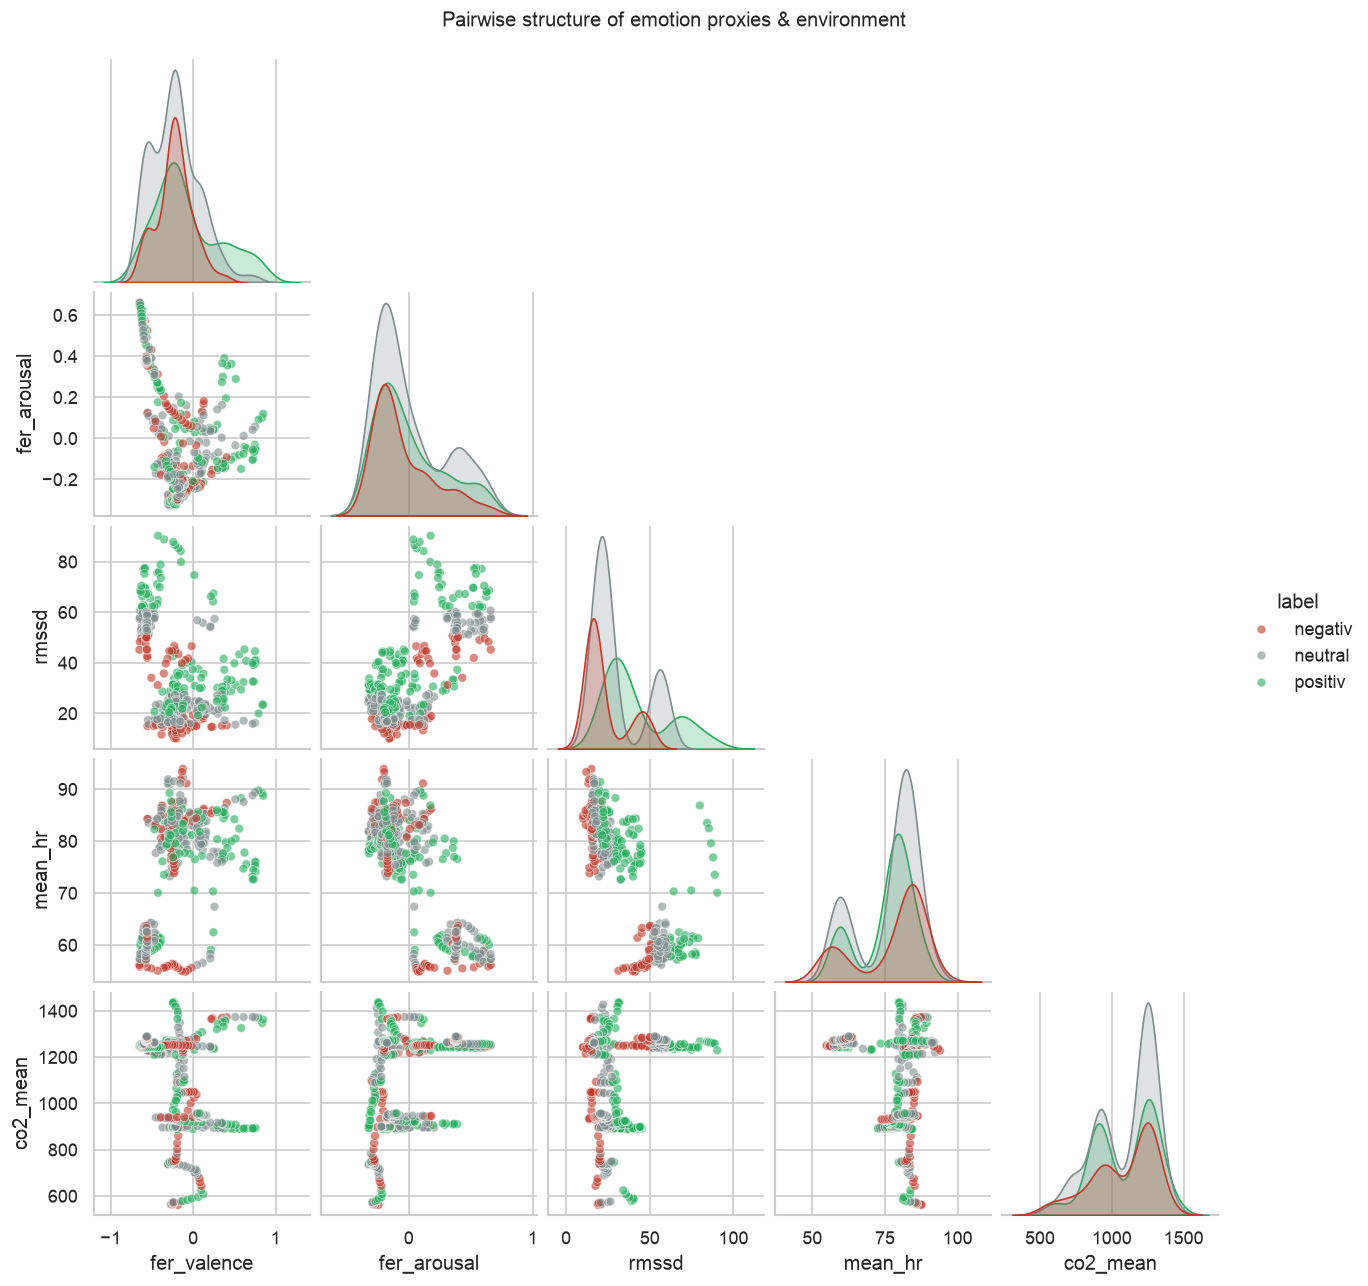

In [10]:
pair_vars = [c for c in ["fer_valence","fer_arousal","rmssd","mean_hr"] if c in df.columns]
pair_vars += env_cols
pair_vars = list(dict.fromkeys(pair_vars))

if len(pair_vars) >= 2 and len(df) >= 5:
    sub = df[pair_vars + [emotion_label]].apply(
        lambda s: pd.to_numeric(s, errors="coerce") if s.name in pair_vars else s
    ).dropna()
    if len(sub) >= 5:
        palette = {"negativ":"#c0392b","neutral":"#7f8c8d","positiv":"#27ae60"}
        g = sns.pairplot(sub, vars=pair_vars, hue=emotion_label,
                         palette=palette, corner=True,
                         plot_kws={"alpha":0.6,"s":28},
                         diag_kind="kde", height=2.1)
        g.fig.suptitle("Pairwise structure of emotion proxies & environment",
                       y=1.02, fontsize=12)
        plt.show()
    else:
        print("Too few complete rows for a pairplot.")
else:
    print("Not enough variables/rows for a pairplot.")


## 7  Results Summary

We consolidate every test into one results table with raw and FDR-adjusted
p-values, the chosen coefficient, the effect size and its interpretation. This
is the table that would go into a paper's results section.


In [11]:
summary_rows = []

# Axis A — emotion vs env
for env_col, res in emotion_env_results.items():
    kw = res["kruskal"]; ordi = res["ordinal"]
    summary_rows.append({
        "axis":"A: emotion↔env","relationship":f"label groups vs {env_col}",
        "method":"Kruskal–Wallis","statistic":round(kw["H"],3),
        "coef":round(kw["epsilon_sq"],3),"coef_name":"ε²",
        "p_raw":kw["p_value"],"n":kw["n_total"]})
    summary_rows.append({
        "axis":"A: emotion↔env","relationship":f"label trend vs {env_col}",
        "method":"Spearman(ordinal)","statistic":np.nan,
        "coef":round(ordi["spearman_r"],3),"coef_name":"ρ",
        "p_raw":ordi["spearman_p"],"n":ordi["n"]})
    for _, r in res["continuous"].iterrows():
        summary_rows.append({
            "axis":"A: emotion↔env","relationship":f"{r['emotion_proxy']} vs {env_col}",
            "method":r["primary_method"],"statistic":np.nan,
            "coef":round(r["primary_r"],3),"coef_name":"r/ρ",
            "p_raw":r["primary_p"],"n":r["n"]})

# Axis B — plant vs env
for env_col, res_df in plant_env_results.items():
    for _, r in res_df.iterrows():
        summary_rows.append({
            "axis":"B: plant↔env","relationship":f"{r['plant_feature']} vs {env_col}",
            "method":r["primary_method"],"statistic":np.nan,
            "coef":round(r["primary_r"],3),"coef_name":"r/ρ",
            "p_raw":r["primary_p"],"n":r["n"]})

summary = pd.DataFrame(summary_rows)
if not summary.empty:
    summary["p_adj"] = fdr_adjust(summary["p_raw"].values)
    summary["significant"] = summary["p_adj"] < ALPHA
    summary["effect"] = summary["coef"].apply(effect_label)
    summary_display = summary.copy()
    summary_display[["p_raw","p_adj"]] = summary_display[["p_raw","p_adj"]].round(4)
    print("CONSOLIDATED RESULTS (FDR-adjusted across all tests):\n")
    print(summary_display.to_string(index=False))
    summary.to_csv("correlation_results.csv", index=False)
    print(f"\n✓ Saved full results to correlation_results.csv")
    n_sig = int(summary["significant"].sum())
    print(f"\nSignificant relationships (FDR-adjusted, α={ALPHA}): {n_sig}/{len(summary)}")
else:
    print("No results to summarise (no environment data available).")


CONSOLIDATED RESULTS (FDR-adjusted across all tests):

          axis             relationship            method  statistic   coef coef_name  p_raw   n  p_adj  significant     effect
A: emotion↔env label groups vs co2_mean    Kruskal–Wallis      0.367 -0.004        ε² 0.8325 456 0.8741        False negligible
A: emotion↔env  label trend vs co2_mean Spearman(ordinal)        NaN -0.003         ρ 0.9531 456 0.9531        False negligible
A: emotion↔env  fer_valence vs co2_mean          Spearman        NaN -0.329       r/ρ 0.0000 456 0.0000         True   moderate
A: emotion↔env  fer_arousal vs co2_mean          Spearman        NaN  0.439       r/ρ 0.0000 456 0.0000         True   moderate
A: emotion↔env        rmssd vs co2_mean          Spearman        NaN  0.155       r/ρ 0.0009 456 0.0013         True      small
A: emotion↔env      mean_hr vs co2_mean          Spearman        NaN -0.130       r/ρ 0.0054 456 0.0069         True      small
  B: plant↔env    plant_zcr vs co2_mean          

## 8  Interpretation & Discussion

*This section interprets whatever the tables above show; the wording below is
framed so it remains correct regardless of the specific values, and points out
how to read them.*

### Axis A — Emotion ↔ CO₂ / VOC
- The **Kruskal–Wallis** test asks whether CO₂ levels differ between
  negative / neutral / positive windows. A significant result (FDR-adjusted
  p < 0.05) with a non-trivial **ε²** would indicate the air-CO₂ level is not
  independent of emotional state. Because CO₂ in a closed room rises with
  breathing rate and metabolic activity — themselves linked to arousal — any
  association is plausibly **mediated by physiology and room ventilation**, not
  a direct emotional signal. This must be stated as a confound, not a causal
  claim.
- The **ordinal trend** (Spearman/Kendall on negativ→neutral→positiv) tells us
  whether CO₂ changes *monotonically* with valence. A near-zero coefficient
  means no ordered relationship even if groups differ.
- The **continuous proxies** (FER valence/arousal, RMSSD, HR) give a finer view;
  arousal-linked measures (HR, RMSSD) are the most likely to track CO₂ via the
  breathing-rate pathway.

### Axis B — Plant Signals ↔ CO₂ / VOC
- Plant electrophysiology is known to respond to environmental variables. A
  significant plant–CO₂ correlation would be scientifically reasonable and is an
  important **control**: it identifies environmental co-variation that could
  otherwise be mistaken for a plant–emotion link.
- The spectral bands `bp_1_5` / `bp_5_15` (classical plant action-potential
  range) and amplitude features (`plant_std`, `plant_rms`) are the most
  physiologically meaningful to inspect; DC-level features (`plant_mean`) are
  less reliable due to the firmware's disabled high-pass and may correlate
  spuriously through slow drift.

### Relation to the overarching research question
This notebook addresses the **environmental half** of the research question
(do CO₂/VOC relate to emotion, and do plant signals relate to CO₂/VOC). The
direct *plant ↔ emotion* link is the subject of the machine-learning notebook;
here we establish whether the **environment** is a shared driver that must be
controlled for when interpreting that link.

### Limitations
- **Pilot sample size.** Wide confidence intervals; non-significant ≠ no effect.
- **Temporal autocorrelation.** Consecutive 30-second windows are not fully
  independent, which can inflate apparent significance. A windowed / mixed-model
  approach is recommended once the full cohort is available.
- **Within-session normalisation** of HRV means emotion proxies are relative to
  each session; cross-session CO₂ comparisons should account for this.
- **VOC currently disabled** — all VOC code is present and will run once
  `ENABLE_VOC = True` and a `voc_mean` column exists.

### Future work
- Re-run on the full cohort and add **partial correlations** controlling for
  participant and session.
- Use **linear mixed-effects models** (participant as random effect) to handle
  repeated windows per person properly.
- If VOC becomes available, test whether VOC adds explanatory power beyond CO₂.

---

*End of correlation analysis. All statistics are reproducible from
`consolidated_dataset.csv`; the full results table is saved to
`correlation_results.csv`.*
